# EDA before Adding Numerical Features

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = "PuRd"

In [14]:
dataset = pd.read_csv("dataset_46443.csv", sep=";")
dataset.head(3)

,filename,year,month,day,hour,minute,lng,lat,alt,camera,width,height,frames,fps,time,mean_brightness,class,bmin,bmax
0,M20251004_190700_MasLaRoca_NE,2025.0,10.0,4.0,19.0,7.0,2.19,41.56,570.0,NE,720.0,576.0,62.0,25.0,0.04,70.666667,unknown,54.0,79.0
1,M20251004_225201_MasLaRoca_NE,2025.0,10.0,4.0,22.0,52.0,2.19,41.56,570.0,NE,720.0,576.0,120.0,25.0,2.40,53.413793,unknown,44.0,63.0
2,M20251005_053814_MasLaRoca_NE,2025.0,10.0,5.0,5.0,38.0,2.19,41.56,570.0,NE,720.0,576.0,62.0,25.0,0.08,40.458333,unknown,39.0,46.0


First, lets select only the features we will need:

In [15]:
features_df = dataset[["filename", "year", "month", "time", "width", "height", "mean_brightness", "bmin", "bmax", "class", "camera"]]
features_df.head(3)

,filename,year,month,time,width,height,mean_brightness,bmin,bmax,class,camera
0,M20251004_190700_MasLaRoca_NE,2025.0,10.0,0.04,720.0,576.0,70.666667,54.0,79.0,unknown,NE
1,M20251004_225201_MasLaRoca_NE,2025.0,10.0,2.40,720.0,576.0,53.413793,44.0,63.0,unknown,NE
2,M20251005_053814_MasLaRoca_NE,2025.0,10.0,0.08,720.0,576.0,40.458333,39.0,46.0,unknown,NE


In [16]:
features_df.describe()

,year,month,time,width,height,mean_brightness,bmin,bmax
count,46443.000000,46443.000000,46443.000000,46443.000000,46443.000000,46443.000000,46443.000000,46443.000000
mean,2025.022415,7.650733,0.816696,548.461247,442.485836,74.712258,52.788278,94.824107
std,0.649899,4.145910,2.994200,252.804539,196.941387,35.166095,24.279023,49.873342
min,2024.000000,1.000000,0.040000,66.000000,67.000000,11.000000,10.000000,11.000000
25%,2025.000000,2.000000,0.040000,238.000000,203.000000,49.333333,39.000000,57.000000
50%,2025.000000,10.000000,0.160000,720.000000,576.000000,64.000000,45.000000,79.000000
75%,2025.000000,11.000000,0.520000,720.000000,576.000000,90.666667,59.000000,123.000000
max,2026.000000,12.000000,113.680000,720.000000,576.000000,255.000000,255.000000,255.000000


In [17]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46443 entries, 0 to 46442
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   filename         46443 non-null  object 
 1   year             46443 non-null  float64
 2   month            46443 non-null  float64
 3   time             46443 non-null  float64
 4   width            46443 non-null  float64
 5   height           46443 non-null  float64
 6   mean_brightness  46443 non-null  float64
 7   bmin             46443 non-null  float64
 8   bmax             46443 non-null  float64
 9   class            46443 non-null  object 
 10  camera           46443 non-null  object 
dtypes: float64(8), object(3)
memory usage: 3.9+ MB


Now, we will take a look at the distribution of each variable:

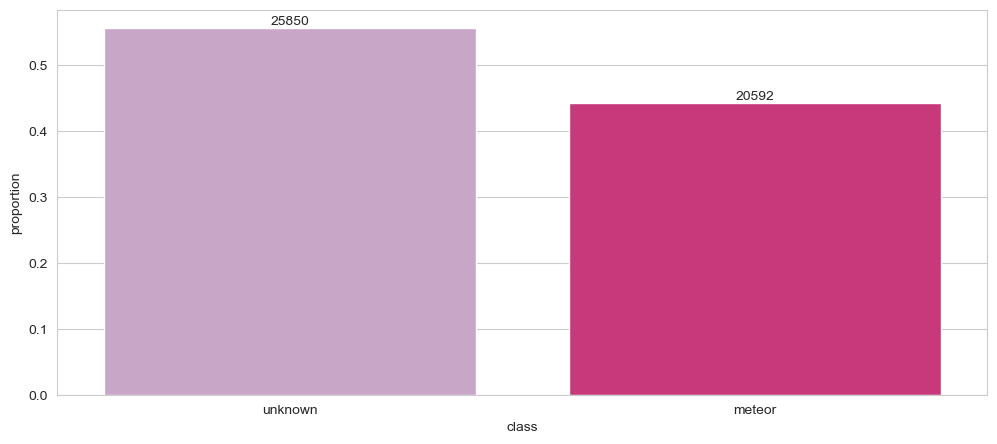

In [18]:
figure, ax = plt.subplots(1, 1, figsize=(12, 5))
sns.countplot(data=features_df, x="class", hue="class", palette=PALETTE, stat='proportion', ax=ax)

total = len(features_df)
for container in ax.containers:
    labels = [f"{int(bar.get_height() * total)}" for bar in container]
    ax.bar_label(container, labels=labels, label_type='edge')

Look at each variable against the class:

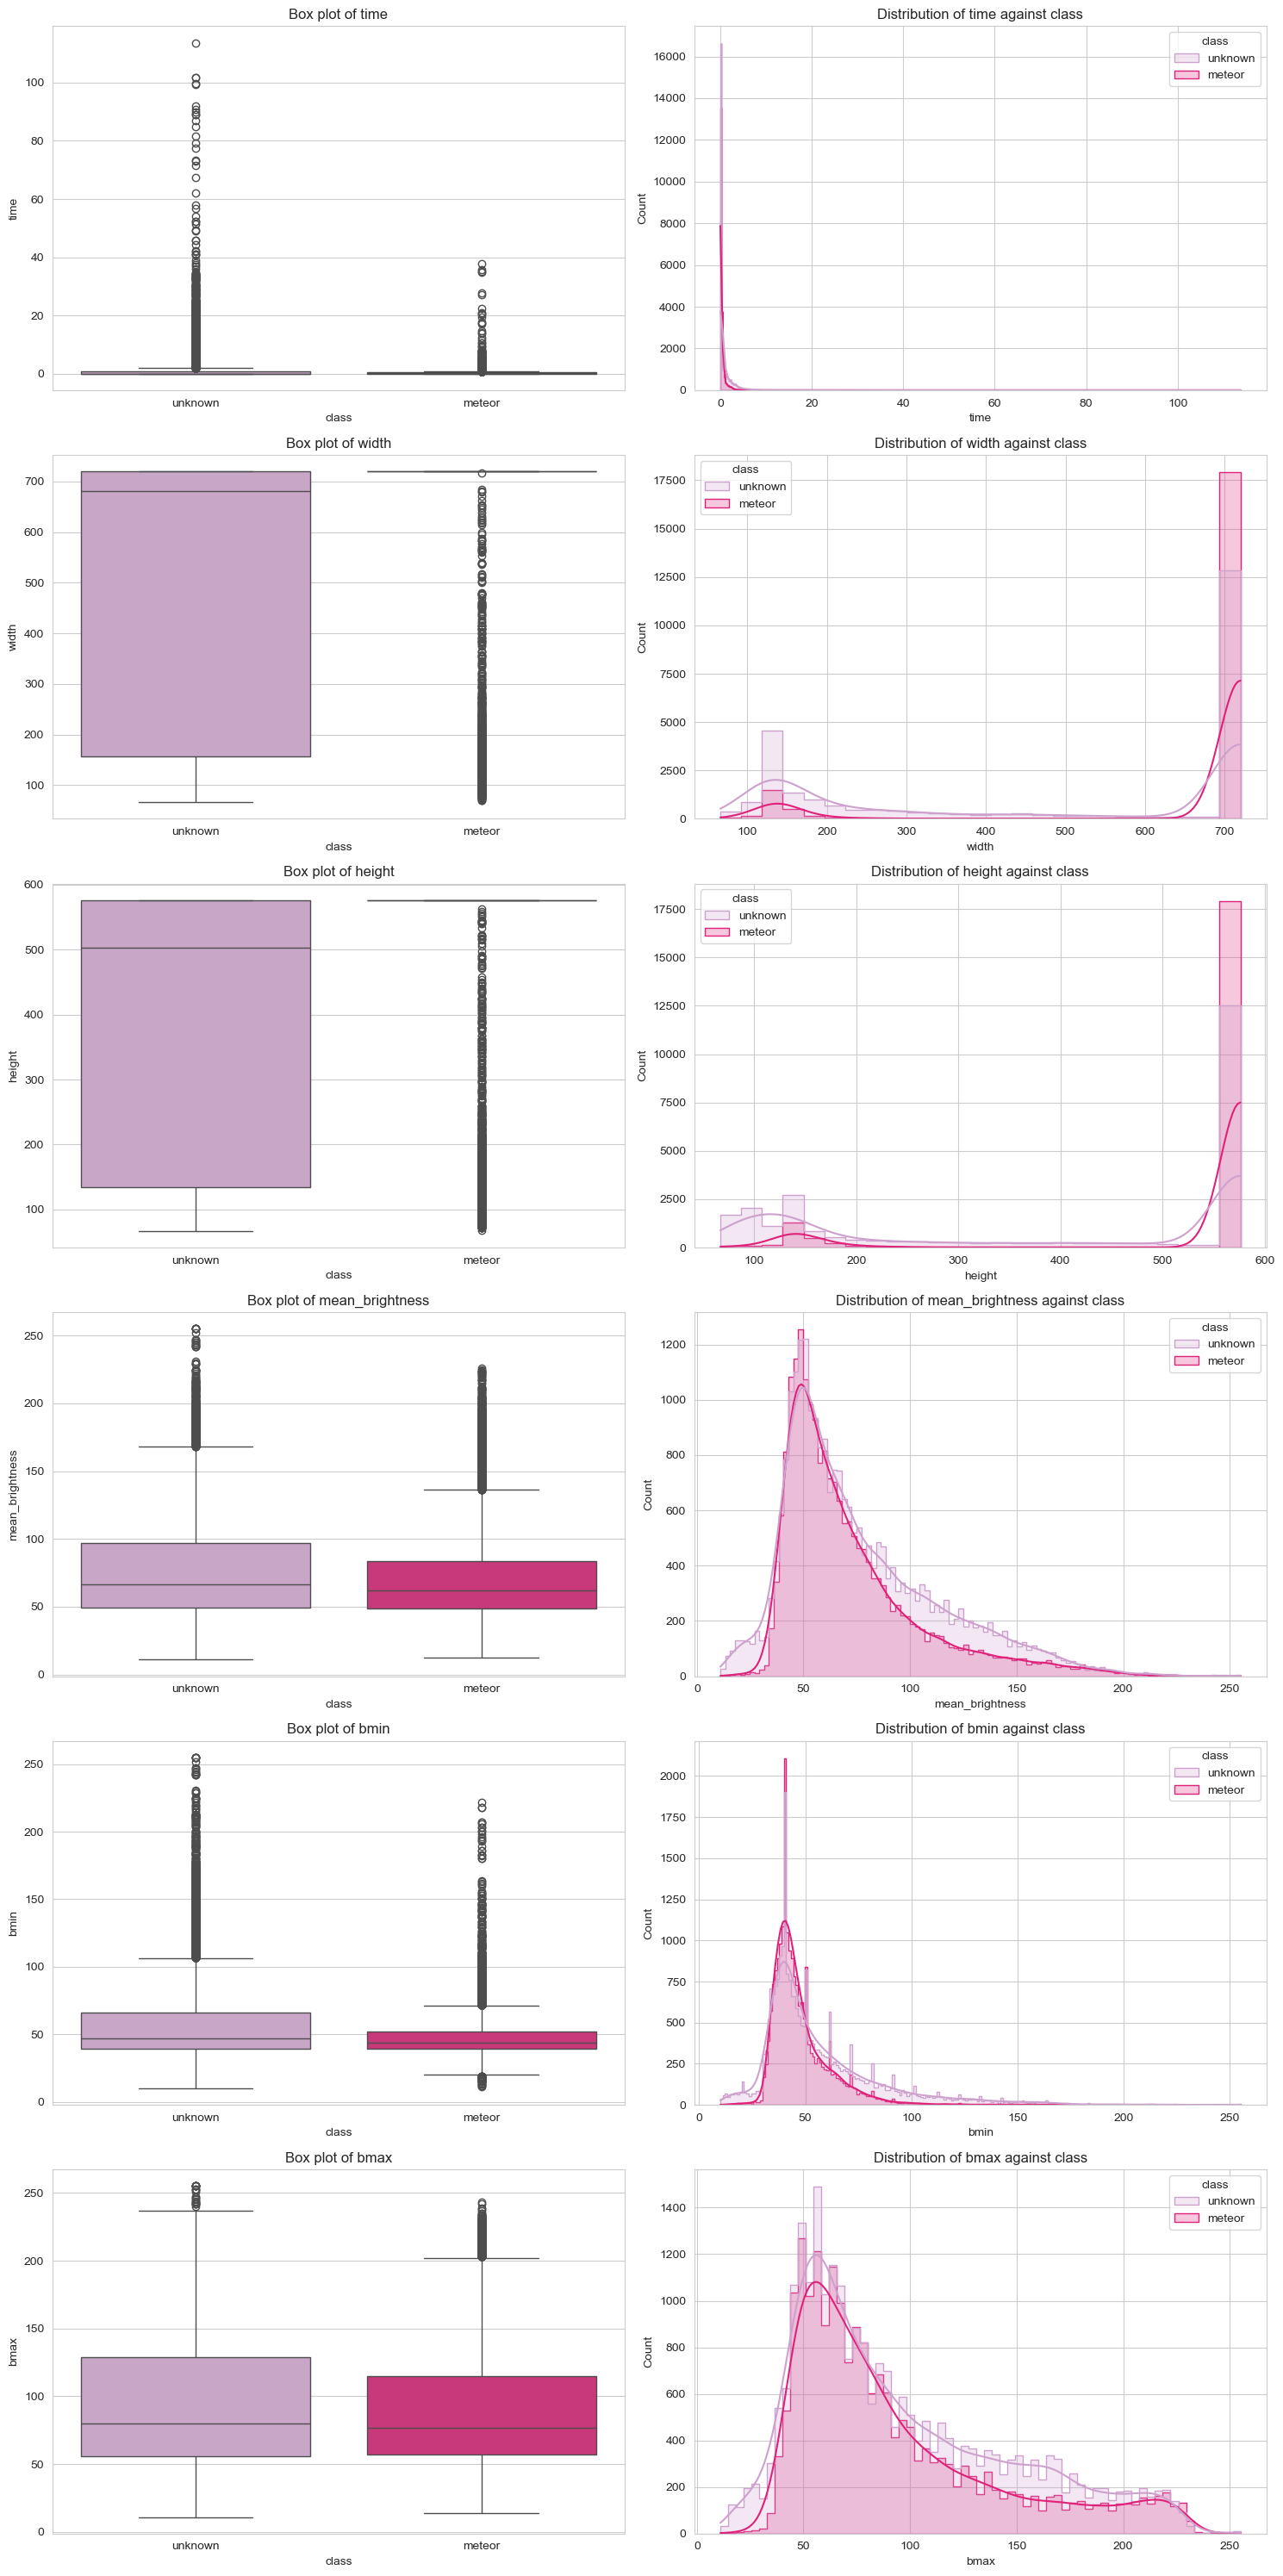

In [ ]:
features_df_temp = features_df.copy(deep=True)
numerical_variables = ["time", "width", "height", "mean_brightness", "bmin", "bmax"]

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Determine the number of rows and columns for the subplot grid
num_vars = len(numerical_variables)
cols = 2  # Two plots for each variable: boxplot and distribution plot
rows = num_vars  # One row for each variable

# Create a figure
fig, axs = plt.subplots(rows, cols, figsize=(15, 5*rows))

# Box plots and distribution plots for numerical variables
for i, column in enumerate(numerical_variables):
    sns.boxplot(x='class', y=column, data=features_df_temp, hue='class', palette=PALETTE, ax=axs[i, 0])
    axs[i, 0].set_title(f'Box plot of {column}')

    sns.histplot(data=features_df_temp, x=column, hue='class', palette=PALETTE, kde=True, element='step', ax=axs[i, 1])
    axs[i, 1].set_title(f'Distribution of {column} against class')

# Adjust layout
plt.tight_layout()
plt.show()

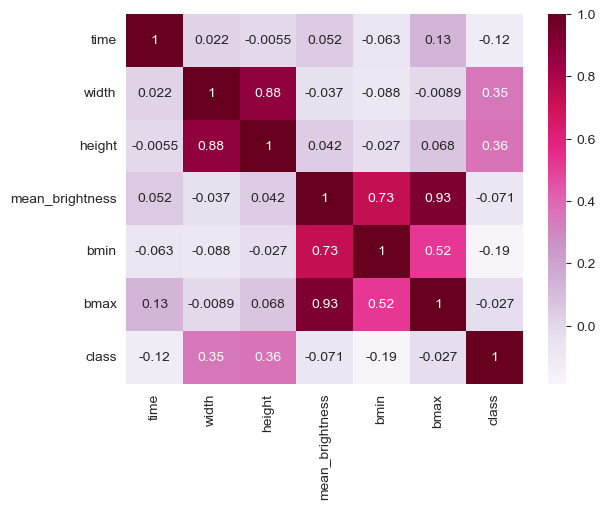

<Figure size 500x500 with 0 Axes>

In [20]:
features_df_temp['class'] = features_df_temp['class'].map({'meteor': 1, 'unknown': 0}).astype(float)

# Construct the correlation matrix with only numerical variables
sns.heatmap(features_df_temp[numerical_variables + ['class']].corr(), cmap=sns.color_palette(PALETTE, as_cmap=True), annot=True)
plt.figure(figsize=(5,5))
plt.show()

## Convert Target Variable

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, RobustScaler

# To make the numerical features smooth, reduce skew and heavy tails, make them robust to outliers, and put them on comparable scale
num_preprocess = Pipeline([
    # To make each distribution more Gaussian-like
    #  - reduces skew, stabilizes variance, makes features more symmetric and easier for linear layers to learn from
    ("power", PowerTransformer(method="yeo-johnson")),

    # Scales each feature using median and interquartile range (instead of mean and std)
    #   - resistant to outliers (many in meteor data), so it prevents them from dominating scale  
    ("scale", RobustScaler())
])

X_num = features_df[numerical_variables]
X_num_norm = num_preprocess.fit_transform(X_num)
X_norm = pd.DataFrame(X_num_norm, columns=numerical_variables)
X_norm.head(3)

,time,width,height,mean_brightness,bmin,bmax
0,-0.383097,0.0,0.0,0.162727,0.436486,0.000000
1,1.210144,0.0,0.0,-0.301632,-0.055546,-0.297184
2,-0.239499,0.0,0.0,-0.776727,-0.360403,-0.716158


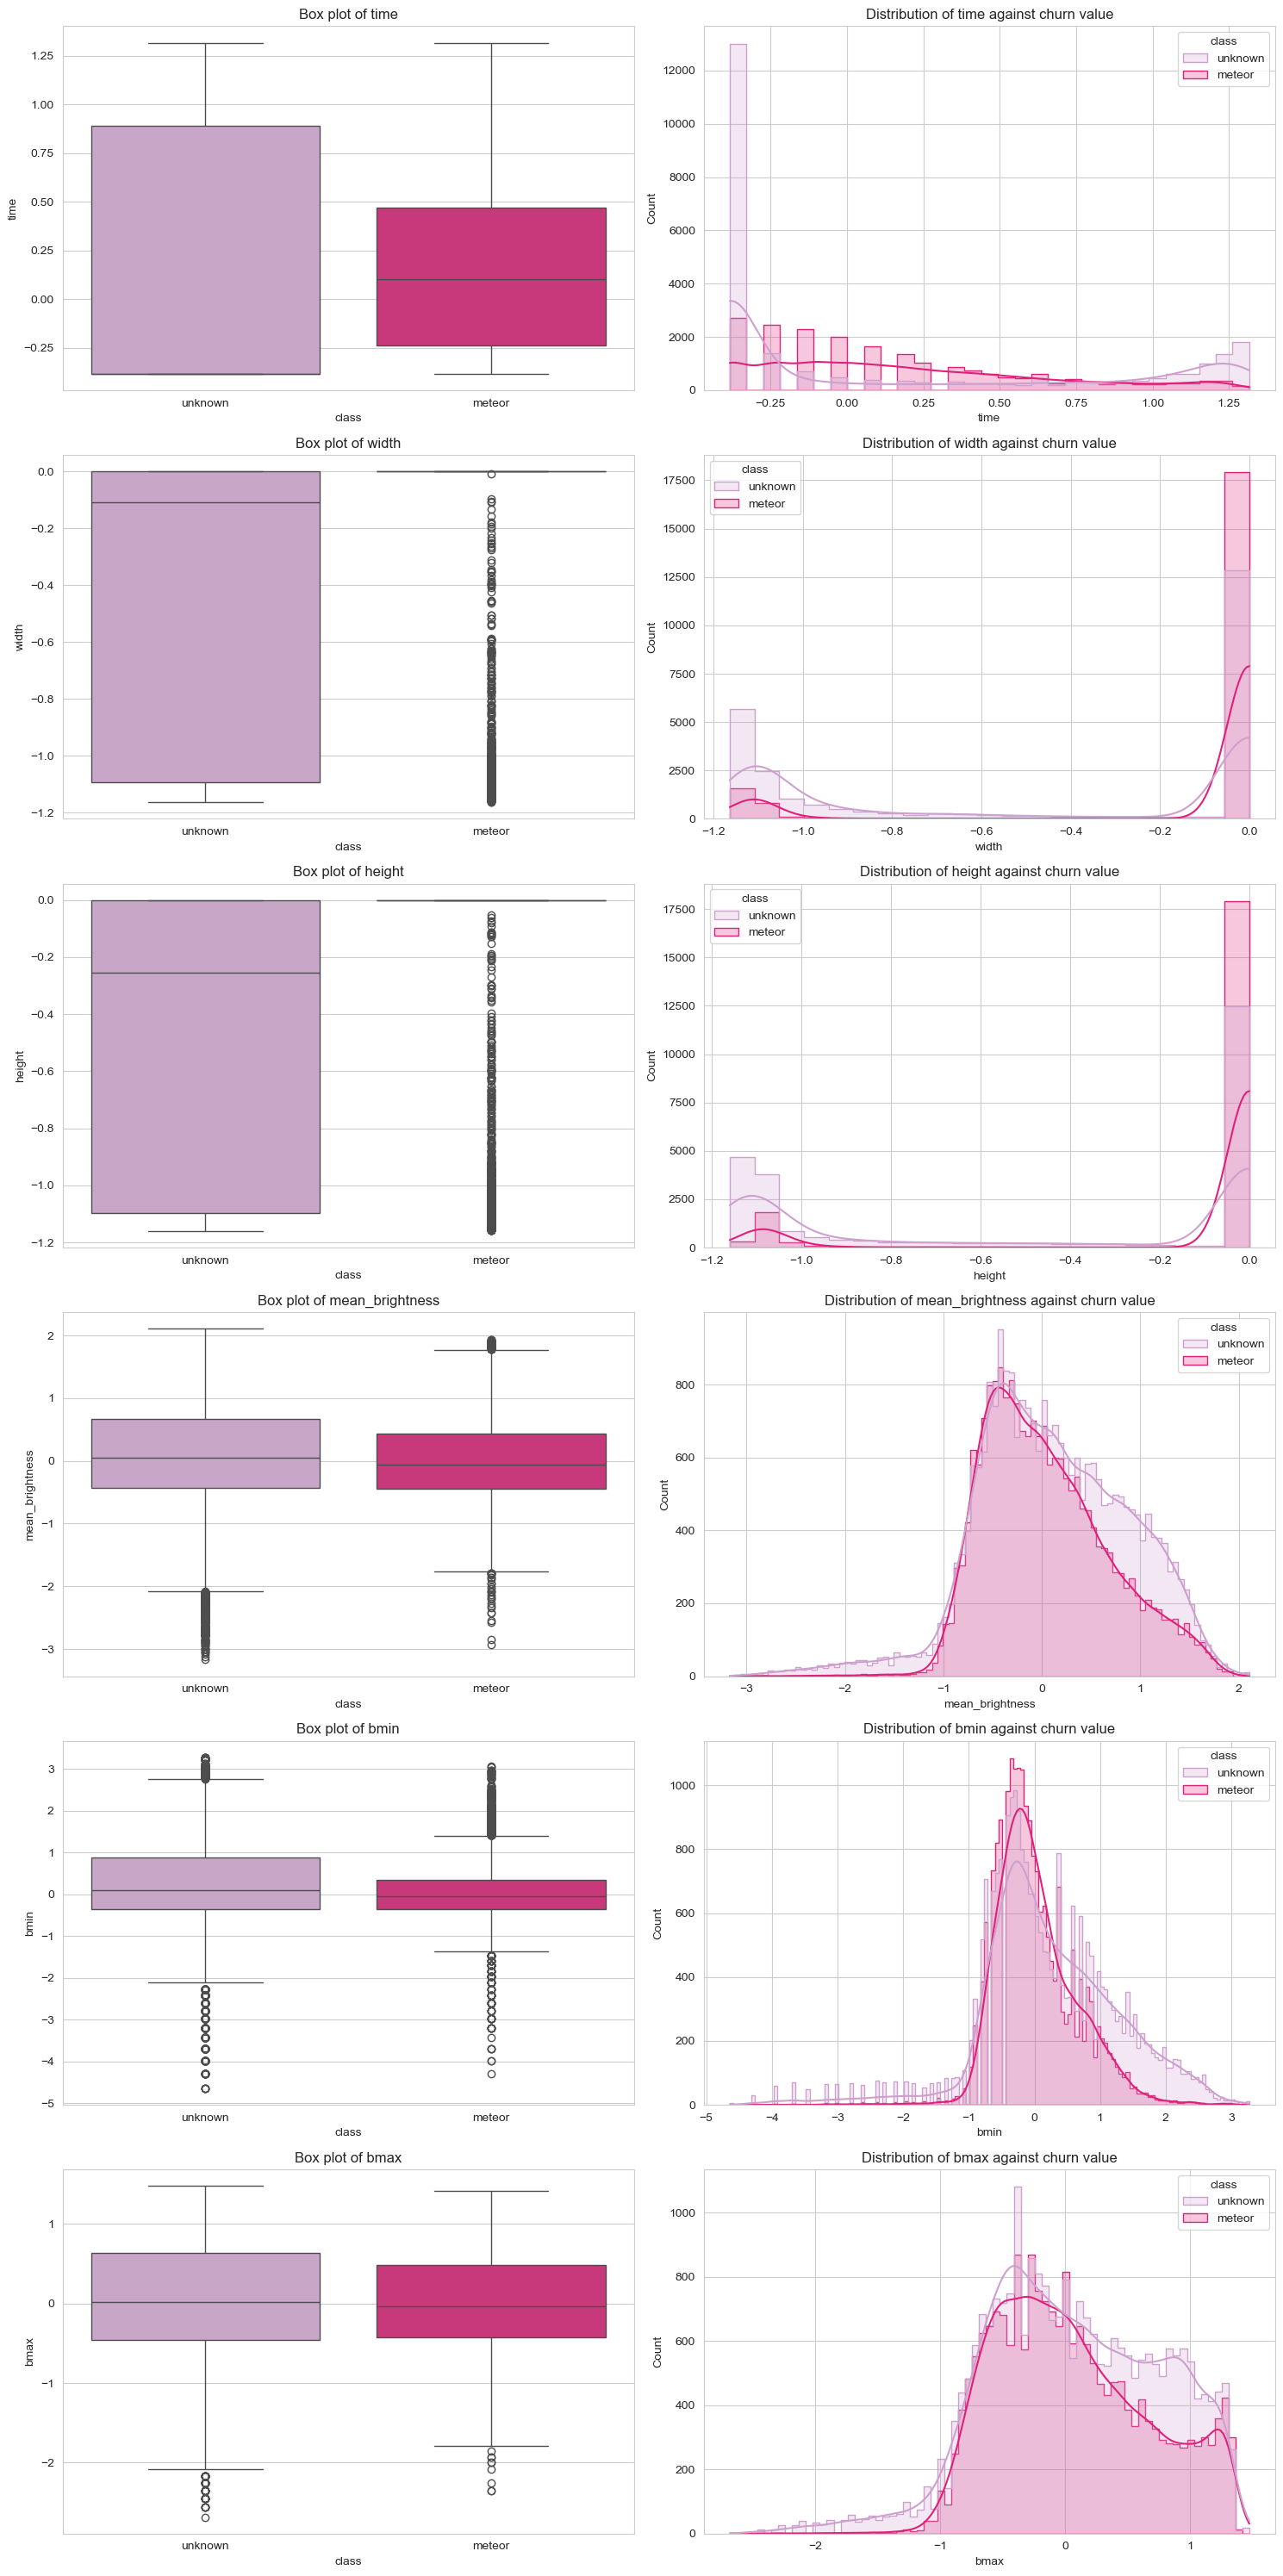

In [22]:
X_norm["class"] = features_df["class"].values

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Determine the number of rows and columns for the subplot grid
num_vars = len(numerical_variables)
cols = 2  # Two plots for each variable: boxplot and distribution plot
rows = num_vars  # One row for each variable

# Create a figure
fig, axs = plt.subplots(rows, cols, figsize=(15, 5*rows))

# Box plots and distribution plots for numerical variables
for i, column in enumerate(numerical_variables):
    sns.boxplot(x='class', y=column, data=X_norm, hue='class', palette=PALETTE, ax=axs[i, 0])
    axs[i, 0].set_title(f'Box plot of {column}')

    sns.histplot(data=X_norm, x=column, hue='class', palette=PALETTE, kde=True, element='step', ax=axs[i, 1])
    axs[i, 1].set_title(f'Distribution of {column} against churn value')

# Adjust layout
plt.tight_layout()
plt.show()